# Загрузка данных

In [23]:
import pandas as pd
import numpy as np
from scipy.stats import normaltest, skew, chi2_contingency, kruskal
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from numpy.random import randint
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import spearmanr

In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data, 
    columns=iris.feature_names
    )

target = iris.target

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


# Отбор числовых признаков

In [4]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

df = df.select_dtypes(include=numerics)

# Функция для определения распределения данных

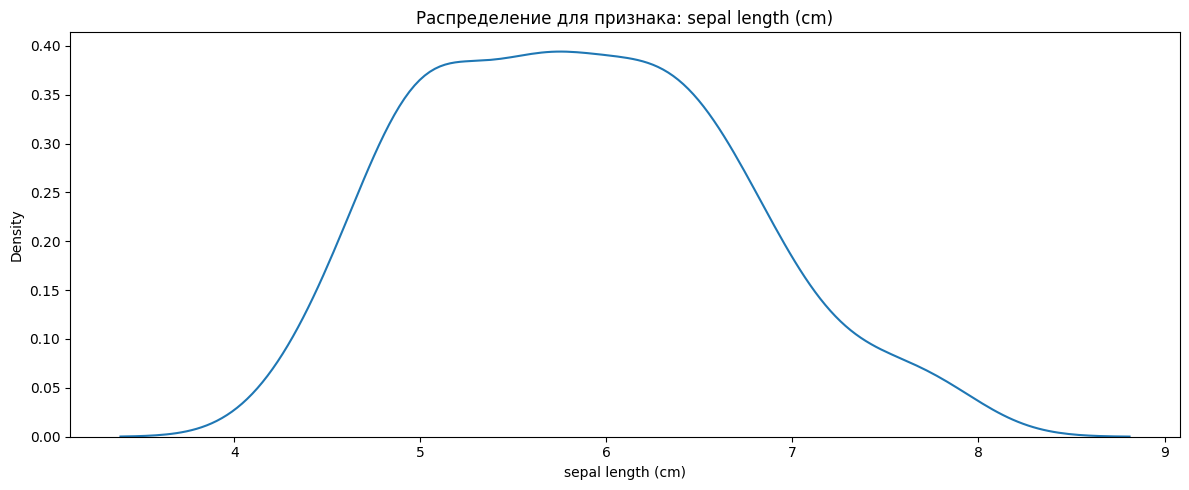

По тесту Д’Агостино-Пирсона нормальность распределения sepal length (cm): True
Скошенность распределения sepal length (cm): Влево


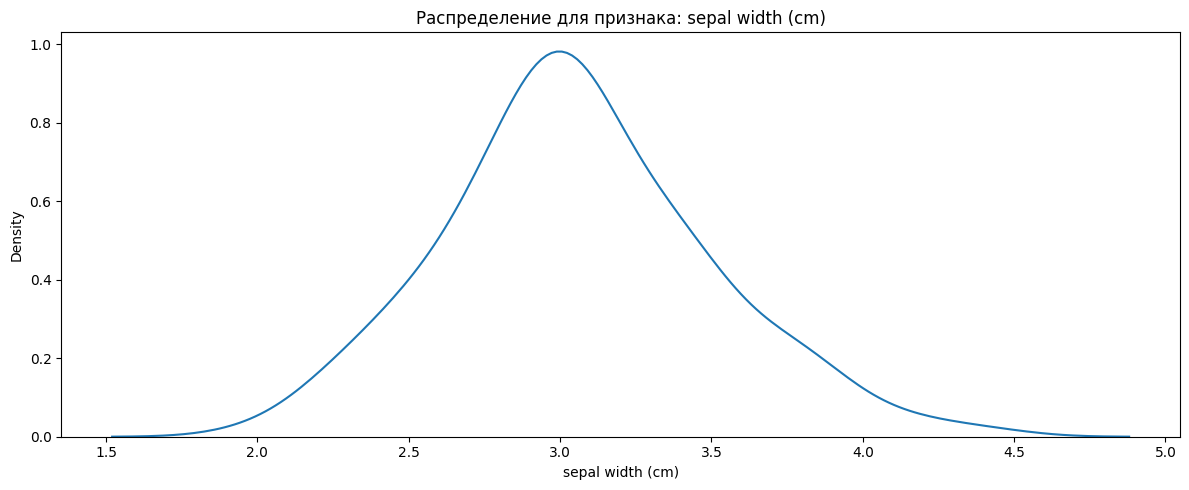

По тесту Д’Агостино-Пирсона нормальность распределения sepal width (cm): True
Скошенность распределения sepal width (cm): Влево


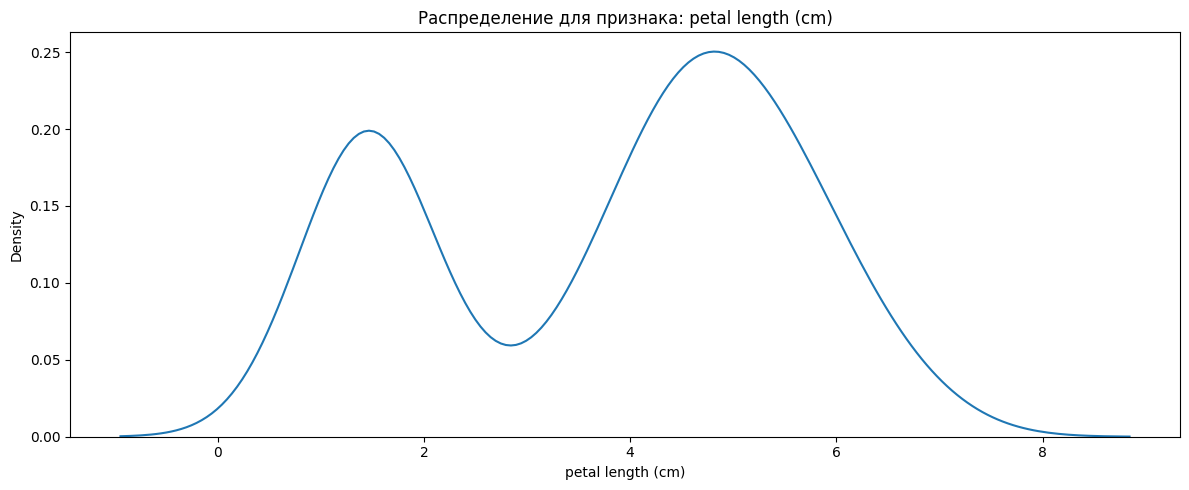

По тесту Д’Агостино-Пирсона нормальность распределения petal length (cm): False
Скошенность распределения petal length (cm): Вправо


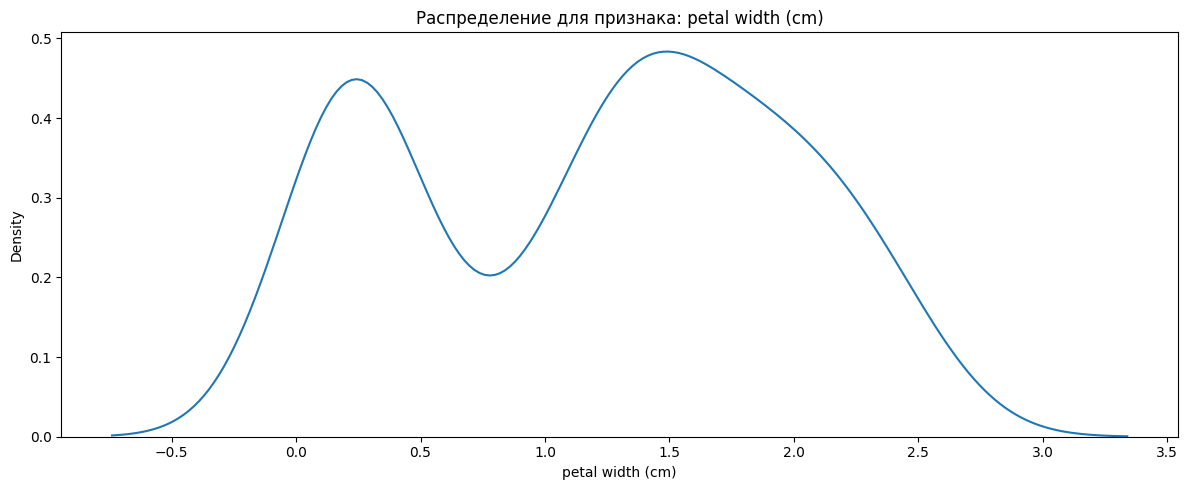

По тесту Д’Агостино-Пирсона нормальность распределения petal width (cm): False
Скошенность распределения petal width (cm): Вправо


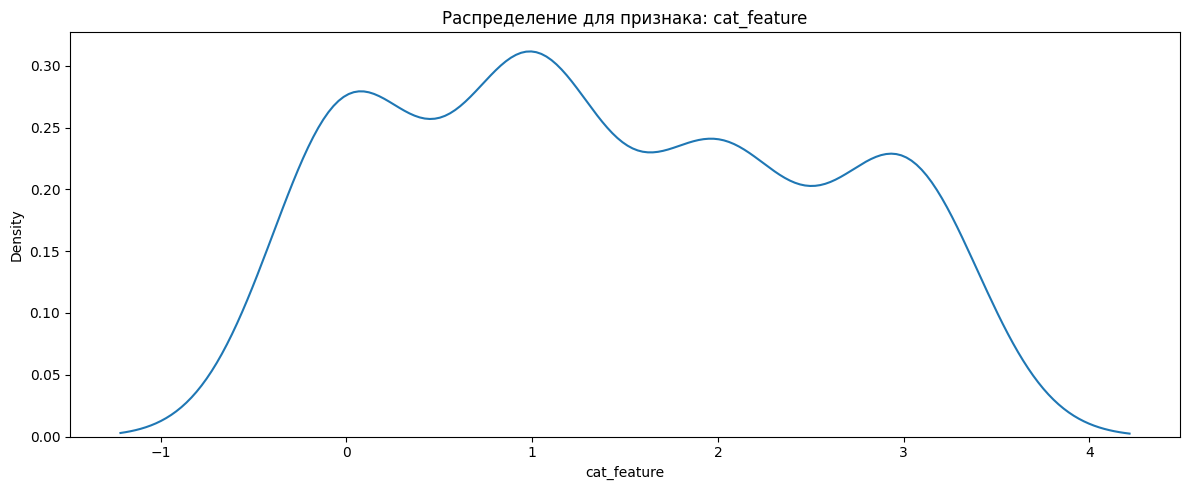

По тесту Д’Агостино-Пирсона нормальность распределения cat_feature: False
Скошенность распределения cat_feature: Влево


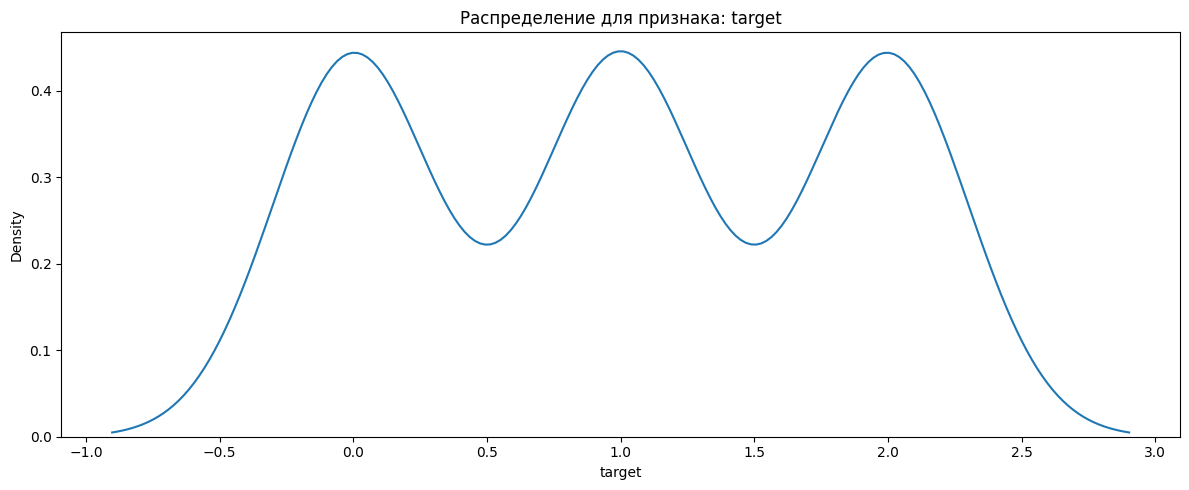

По тесту Д’Агостино-Пирсона нормальность распределения target: False
Скошенность распределения target: Не выявлено


In [25]:
# Тест Д’Агостино-Пирсона
def execute_normaltest(data):
    result = normaltest(data)
    p_value = result[1]
    
    return p_value

# Тест на ассиметрию
def get_assymetry(data):
    result = skew(data)

    if result > 0.1:
        return "Влево"
    elif result < -0.1:
        return "Вправо"
    return "Не выявлено"

def visual_distribution(data, column):

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.kdeplot(data=data, x=column, ax=ax)
    ax.set_title(f"Распределение для признака: {column}")

    fig.tight_layout()
    plt.show()

    normaltest_p_value = execute_normaltest(data[column])
    print(f"По тесту Д’Агостино-Пирсона нормальность распределения {column}: {normaltest_p_value > 0.05}")

    assymetry = get_assymetry(data[column])
    print(f"Скошенность распределения {column}: {assymetry}")


for col in df.columns:
    visual_distribution(df, col)

Тест Д'Агостино-Пирсона (normaltest) был выбран как основной критерий проверки нормальности распределения по нескольким важным причинам. В отличие от широко известного теста Шапиро-Уилка, который оптимален только для малых выборок (n < 50), normaltest демонстрирует хорошую эффективность на выборках любого размера. Этот тест комбинирует проверку двух ключевых параметров распределения - асимметрии (skewness) и эксцесса (kurtosis), что позволяет комплексно оценить отклонение от нормальности. Особенно важно, что тест сохраняет точность даже при наличии умеренных выбросов в данных, что критично для реальных датасетов. Результат теста интерпретируется классическим образом через p-value с порогом 0.05, что соответствует общепринятой статистической практике.

Анализ асимметрии через функцию get_assymetry дополняет картину, давая качественную оценку направления скошенности распределения. Использование порога 0.1 для определения значимой асимметрии является разумным компромиссом между чувствительностью и устойчивостью к случайным колебаниям. Такой подход позволяет быстро идентифицировать случаи, когда данные смещены влево (преобладание высоких значений) или вправо (преобладание низких значений), что имеет важное значение для последующего выбора методов обработки и анализа.

Визуализация через kdeplot представляет собой оптимальный баланс между информативностью и наглядностью. Ядерные оценки плотности (KDE) эффективно демонстрируют форму распределения, выделяя модальность (наличие пиков), скошенность и другие особенности. В сочетании с числовыми тестами, такой график позволяет не только формально оценить свойства распределения, но и визуально проверить выводы, что снижает риск ошибочной интерпретации. Особенно важно, что визуализация помогает выявить бимодальность или другие сложные формы распределения, которые могут быть неочевидны из числовых тестов.

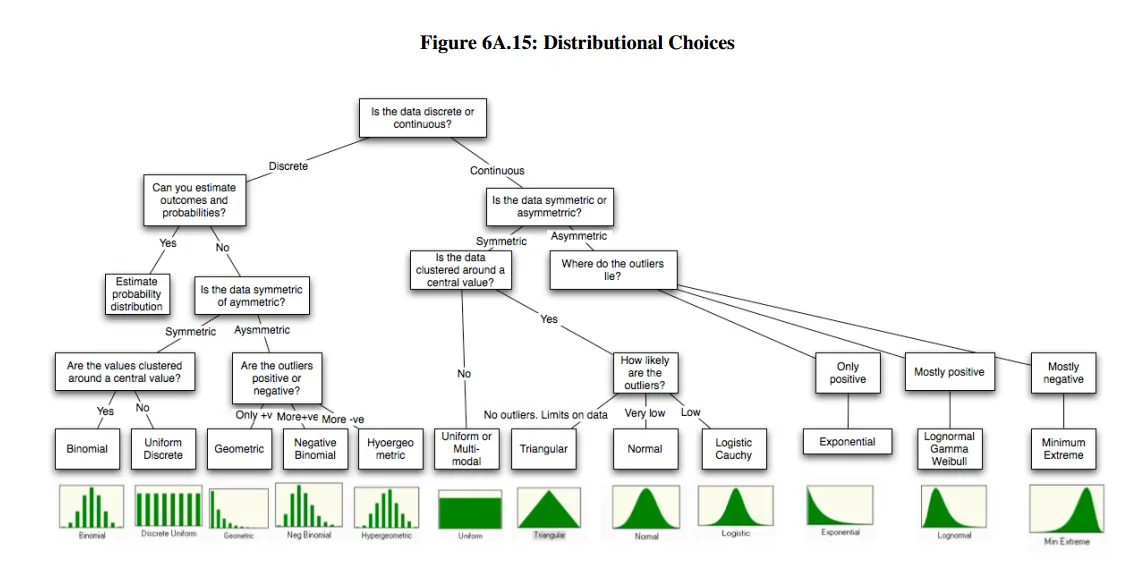

* Binomial - биномиальное
* Uniform Discrete - равномерное дискретное
* Geometric - геометрическое
* Negative Binomial - отрицательное биномиальное
* Hyoergeometric - гипергеометрическое
* Uniform or Mulitmodal - равномерное или мультимодальное
* Triangular - треугольное
* Normal - нормальное
* Logistic Cauchy -  распределение Коши (но чаще - это именно распределение Стьюдента)
* Exponential - экспоненциальное
* Lognormal/Gamma/Weibull - логарифмическое нормальное
* Minimum Extreme - минимальное экстремальное

# Корреляция данных

## Корреляция непрерывная - непрерывная

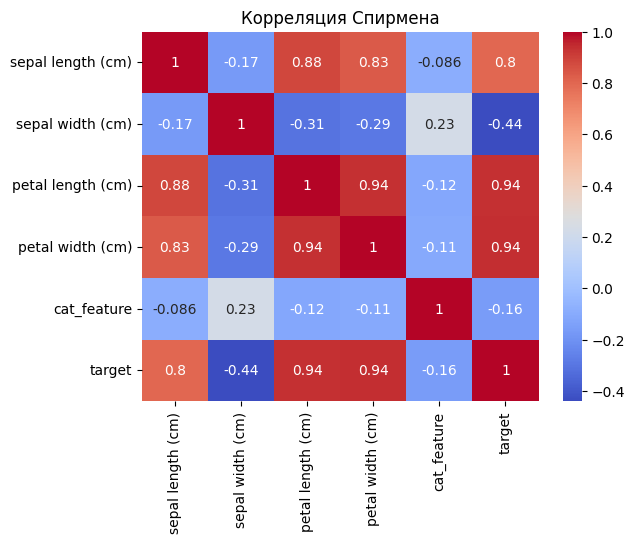

In [27]:
corr_type = "spearman" # Тип корреляции (pearson, spearman, kendall)

sns.heatmap(df.corr(corr_type), annot=True, cmap="coolwarm")
plt.title("Корреляция Спирмена")
plt.show()

### Выбери нужный

Для оценки линейной связи между признаками был выбран коэффициент корреляции Пирсона, так как оба признака демонстрируют нормальное распределение (проверено тестом Д’Агостино-Пирсона), а визуальный анализ (график рассеяния) подтвердил отсутствие значимых выбросов и линейный характер зависимости. Корреляция Пирсона оптимальна для таких условий, так как она точно оценивает силу и направление линейной связи.

Область применения:

Оба признака имеют нормальное распределение (проверяется тестами на нормальность: Шапиро-Уилка, Д’Агостино-Пирсона).

Связь между признаками линейная (проверяется через scatter plot).

Данные не содержат значимых выбросов, которые могут исказить результат.

Поскольку данные не соответствуют предположению о нормальности распределения (p-value < 0.05), для анализа зависимости был применён коэффициент корреляции Спирмена. Этот метод оценивает монотонную связь, что позволяет выявить нелинейные, но устойчивые зависимости (например, экспоненциальные или логарифмические). График рассеяния подтвердил отсутствие линейности, но показал наличие монотонного роста/убывания значений.

Область применения:

Данные не нормальны (например, имеют скошенность или выбросы).

Связь монотонная (возрастающая или убывающая, но не обязательно линейная).

Наличие ранговых данных или порядковых шкал.

Для анализа связи между признаками был выбран коэффициент корреляции Кендалла, так как данные содержат множество совпадающих значений (повторов), а размер выборки относительно мал (n < 30). Метод Кендалла менее чувствителен к выбросам и лучше подходит для ранговых данных, обеспечивая более консервативную оценку связи по сравнению со Спирменом.

Область применения:

Малая выборка (n < 30) или данные с повторяющимися значениями.

Требуется устойчивость к выбросам.

Данные имеют ранговую природу (например, оценки или порядковые шкалы).

## Корреляция категориальная - категориальная

In [ ]:
cat_feature = randint(0, 4, len(target)) # Генерация категориального признака

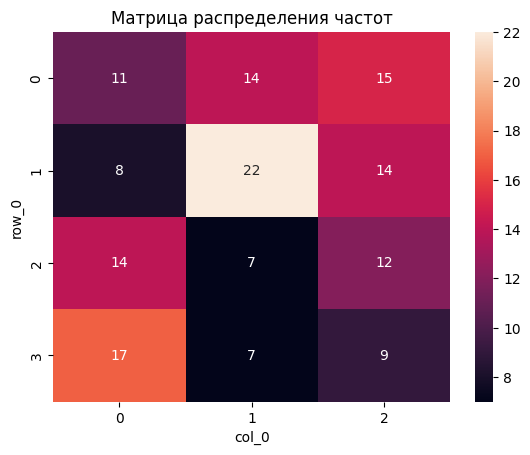

In [8]:
sns.heatmap(pd.crosstab(cat_feature, target), annot=True)
plt.title("Матрица распределения частот")
plt.show()

Для визуальной оценки взаимосвязи между категориальными признаками была построена тепловая карта на основе таблицы сопряжённости (crosstab). Этот метод позволяет наглядно:

Сравнить распределение частот комбинаций категорий.

Выявить аномальные сочетания (ячейки с неожиданно высокими/низкими значениями).

Обнаружить потенциальные зависимости даже без статистических тестов.

Тепловая карта особенно полезна при работе с номинальными данными (без естественного порядка), где классические меры корреляции неприменимы. Цветовая шкала (аннотированная абсолютными значениями) помогает быстро интерпретировать силу связи.

In [9]:
# Тест на корреляцию между двумя переменными (хи-квадрат)
def get_chi_2(cat_1, cat_2):
    chi2, p_value, _, _ = chi2_contingency(pd.crosstab(cat_1, cat_2))

    if p_value < 0.05:
        return f"p-value = {p_value:.4f}. Корреляция между переменными есть (зависимость)."
    else:
        return f"p-value = {p_value:.4f}. Корреляции между переменными нет (независимость)."

In [10]:
get_chi_2(cat_feature, target)

'p-value = 0.0216. Корреляция между переменными есть (зависимость).'

In [11]:
get_chi_2(target, target)

'p-value = 0.0000. Корреляция между переменными есть (зависимость).'

Для проверки статистической значимости связи между категориальными переменными был применён критерий хи-квадрат Пирсона. Нулевая гипотеза (H₀) предполагает независимость признаков.

Результаты теста:

При p-value < 0.05: Отвергаем H₀ — существует значимая зависимость между переменными.

При p-value ≥ 0.05: Нет оснований отвергать H₀ — признаки независимы.

Тест дополняет визуальный анализ, предоставляя количественную оценку достоверности наблюдаемых закономерностей.

## Корреляция непрерывная - категориальная

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size = 0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

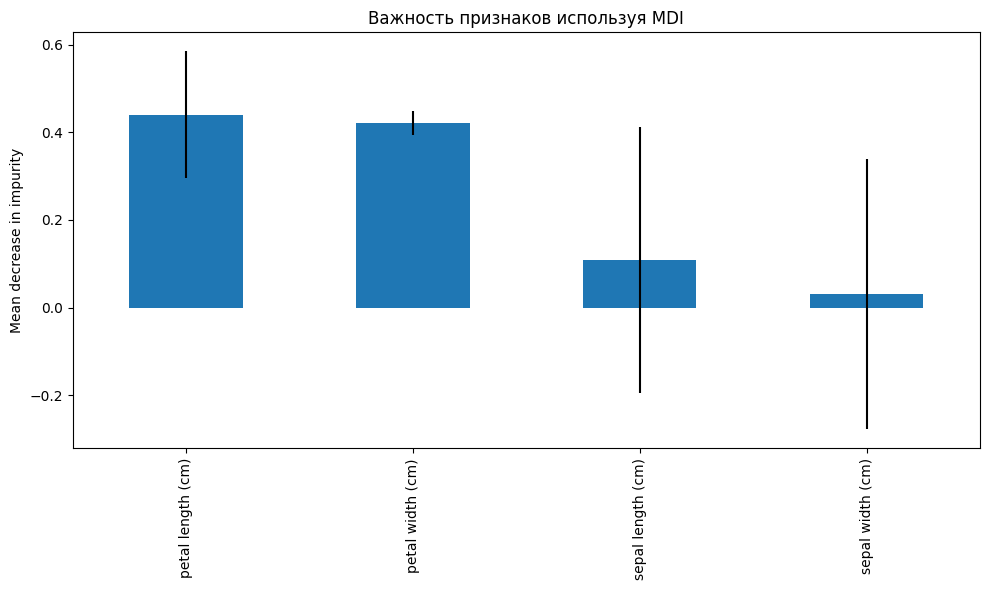

In [13]:
importances = clf.feature_importances_

std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=df.columns).sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Важность признаков используя MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

Random Forest с MDI — идеальный метод для анализа связи категориальных и непрерывных признаков, так как:

Работает с любыми типами данных без предобработки

Выявляет сложные нелинейные зависимости, которые не могут обнаружить стандартные тесты

Дает количественную оценку важности каждого признака через уменьшение неопределенности (impurity)

Устойчив к выбросам и перекосу в данных

Визуализация с доверительными интервалами (через std) показывает надежность оценок

График важности признаков наглядно ранжирует их по влиянию на целевую переменную, что делает анализ интуитивно понятным. Метод особенно полезен, когда:

Есть смесь категориальных и непрерывных признаков

Зависимости сложные и нелинейные

Нужно оценить относительную важность многих предикторов сразу

Этот подход превосходит традиционные статистические тесты для подобных задач, сочетая гибкость машинного обучения с интерпретируемостью.

## Корреляция категориальная - непрерывная

In [14]:
df["cat_feature"] = cat_feature
df["target"] = target

In [15]:
# Тест Краскела-Уоллиса (категориальный -> непрерывный)
def kruskal_wallis_test(cat_feature, cont_feature):
    groups = []
    for cat in df[cat_feature].unique():
        groups.append(df[df[cat_feature] == cat][cont_feature])
    
    stat, p_value = kruskal(*groups)
    
    if p_value < 0.05:
        return f"p-value = {p_value:.4f}. Есть статистически значимые различия между группами."
    else:
        return f"p-value = {p_value:.4f}. Нет значимых различий между группами."

In [38]:
def get_cat_cont_plots(cat_feature, cont_feature):
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))
    sns.barplot(data=df, x=cat_feature, y=cont_feature, estimator=np.mean, ax=axes[0])
    sns.boxplot(data=df, x=cat_feature, y=cont_feature, ax=axes[1])
    fig.suptitle(f"Распределение для признака: {cont_feature}")
    plt.show()

    print("По тесту Краскела-Уоллиса:", kruskal_wallis_test(cat_feature, cont_feature))

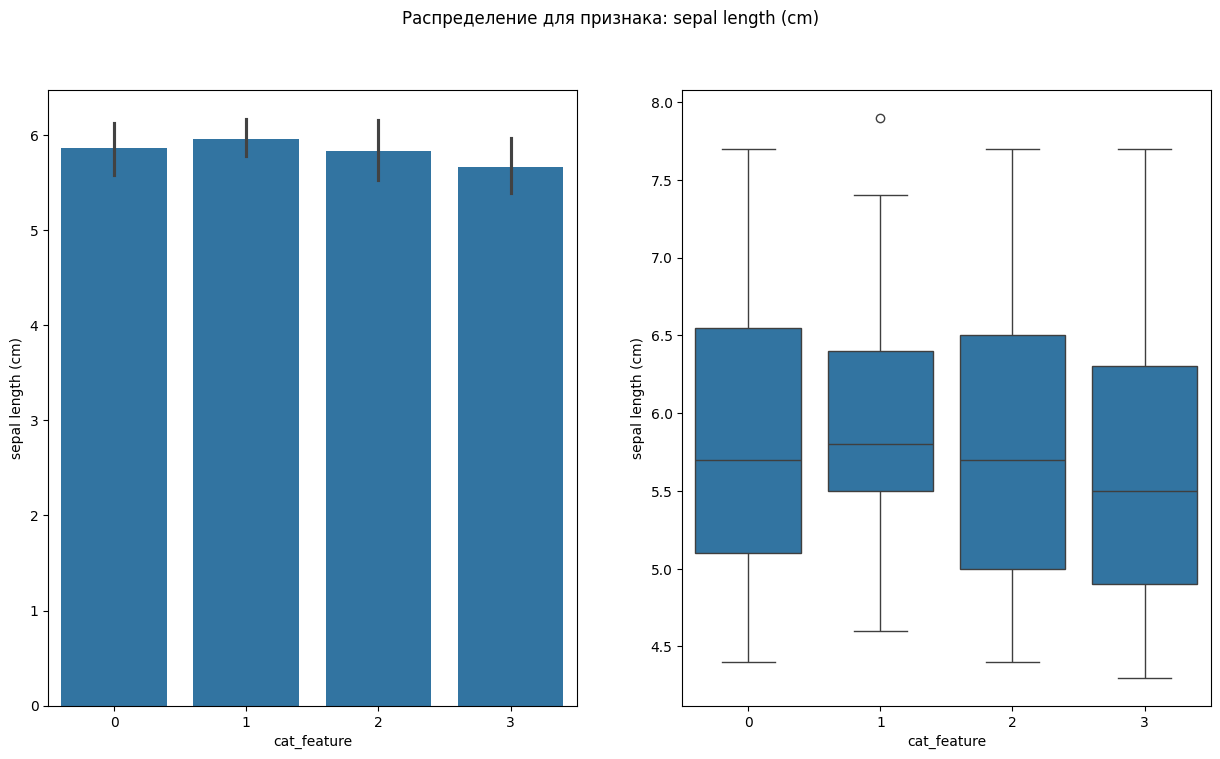

По тесту Краскела-Уоллиса: p-value = 0.4034. Нет значимых различий между группами.


In [39]:
get_cat_cont_plots("cat_feature", "sepal length (cm)")

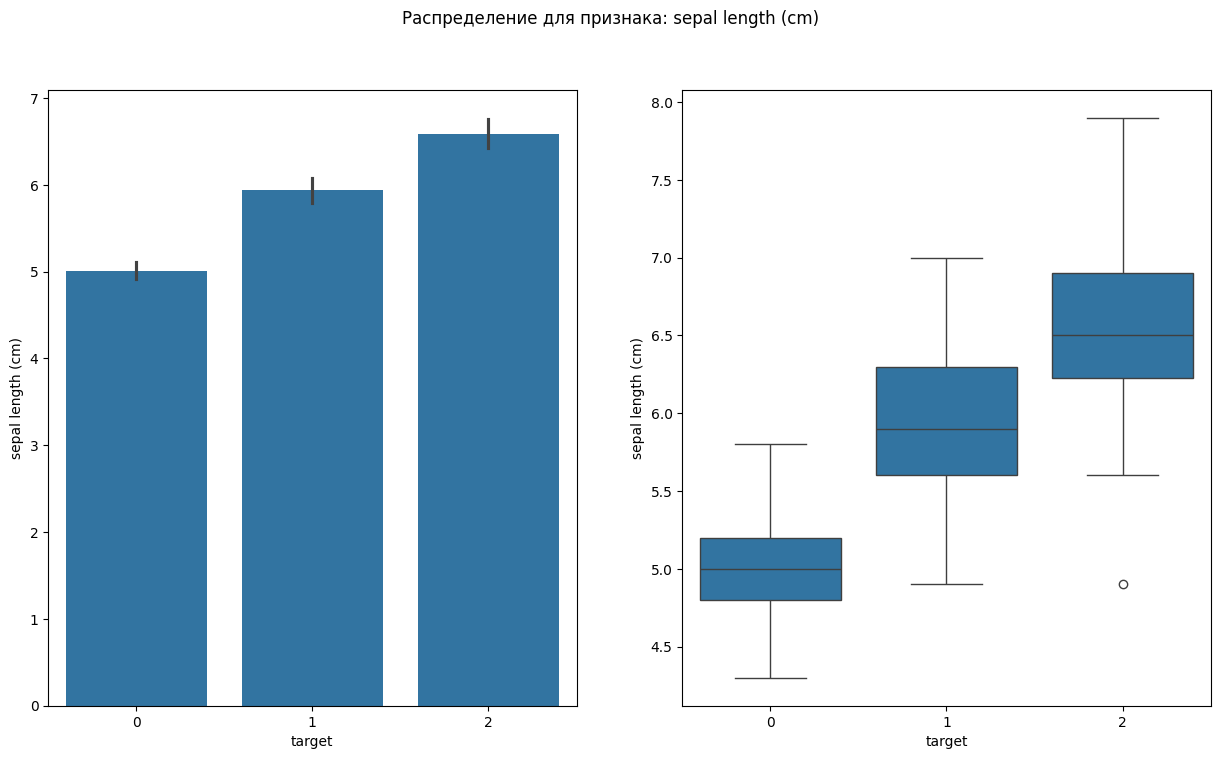

По тесту Краскела-Уоллиса: p-value = 0.0000. Есть статистически значимые различия между группами.


In [40]:
get_cat_cont_plots("target", "sepal length (cm)")

1. Тест Краскела-Уоллиса как ядро анализа
Этот непараметрический тест является идеальным выбором для сравнения непрерывного признака между несколькими категориальными группами по трём ключевым причинам. Во-первых, он не требует нормального распределения данных внутри групп, что критически важно при работе с реальными данными, которые часто имеют выбросы или асимметрию. Во-вторых, тест устойчив к неравным дисперсиям между группами (гетероскедастичности), что часто встречается на практике. В-третьих, он позволяет сравнивать более двух групп одновременно, в отличие от парных тестов, экономя наши вычислительные ресурсы и избегая проблемы множественных сравнений.

2. Визуализация через barplot и boxplot
Двойная визуализация выполняет две взаимодополняющие функции. Barplot с средними значениями даёт мгновенное понимание центральных тенденций в группах, что особенно полезно для презентации результатов нестатистической аудитории. Boxplot же раскрывает детали распределения - медиану, квартили, выбросы и разброс значений, позволяя оценить гомогенность групп и обнаружить потенциальные аномалии. Такое сочетание графиков обеспечивает полную картину данных.

## Корреляция порядковая категориальная - непрерывная/порядковая категориальная

In [41]:
# Проверяет монотонную корреляцию между двумя непрерывными или порядковыми признаками.
def spearman_corr(feature1, feature2):
    corr, p_value = spearmanr(df[feature1], df[feature2])
    
    if p_value < 0.05:
        return f"p-value = {p_value:.4f}. Есть статистически значимая монотонная корреляция (ρ = {corr:.2f})."
    else:
        return f"p-value = {p_value:.4f}. Нет значимой монотонной корреляции (ρ = {corr:.2f})."

In [42]:
def get_ord_cont_plots(ord_feature, cont_feature):
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))
    sns.barplot(data=df, x=ord_feature, y=cont_feature, estimator=np.mean, ax=axes[0])
    sns.boxplot(data=df, x=ord_feature, y=cont_feature, ax=axes[1])
    fig.suptitle(f"Распределение для признака: {cont_feature}")
    plt.show()

    print("По тесту Спирмена:", spearman_corr(ord_feature, cont_feature))

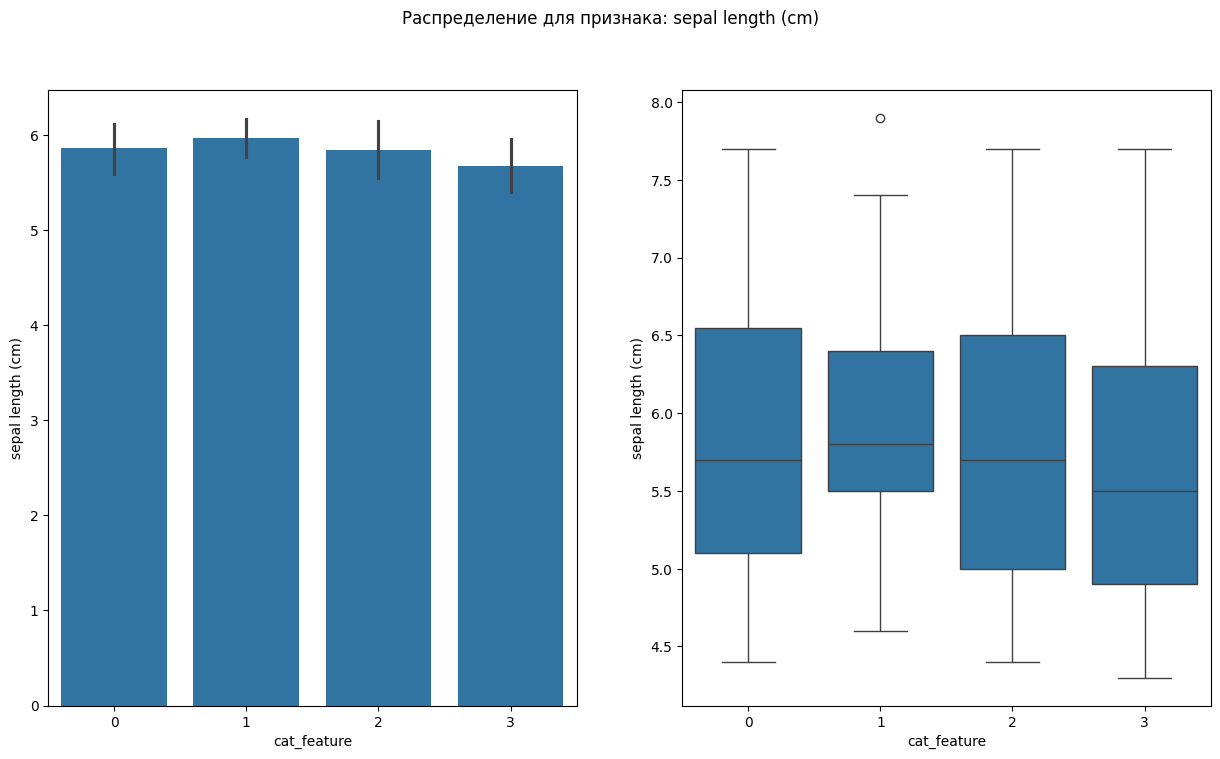

По тесту Спирмена: p-value = 0.2962. Нет значимой монотонной корреляции (ρ = -0.09).


In [43]:
get_ord_cont_plots("cat_feature", "sepal length (cm)")

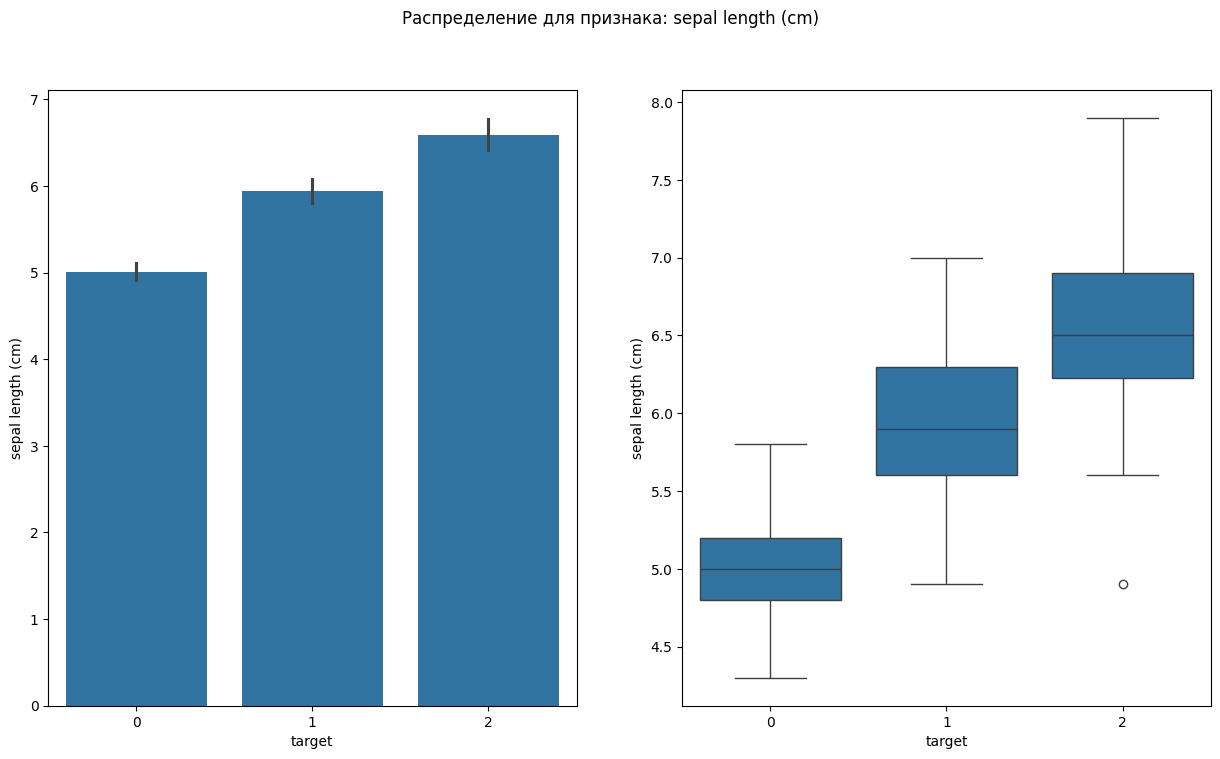

По тесту Спирмена: p-value = 0.0000. Есть статистически значимая монотонная корреляция (ρ = 0.80).


In [44]:
get_ord_cont_plots("target", "sepal length (cm)")

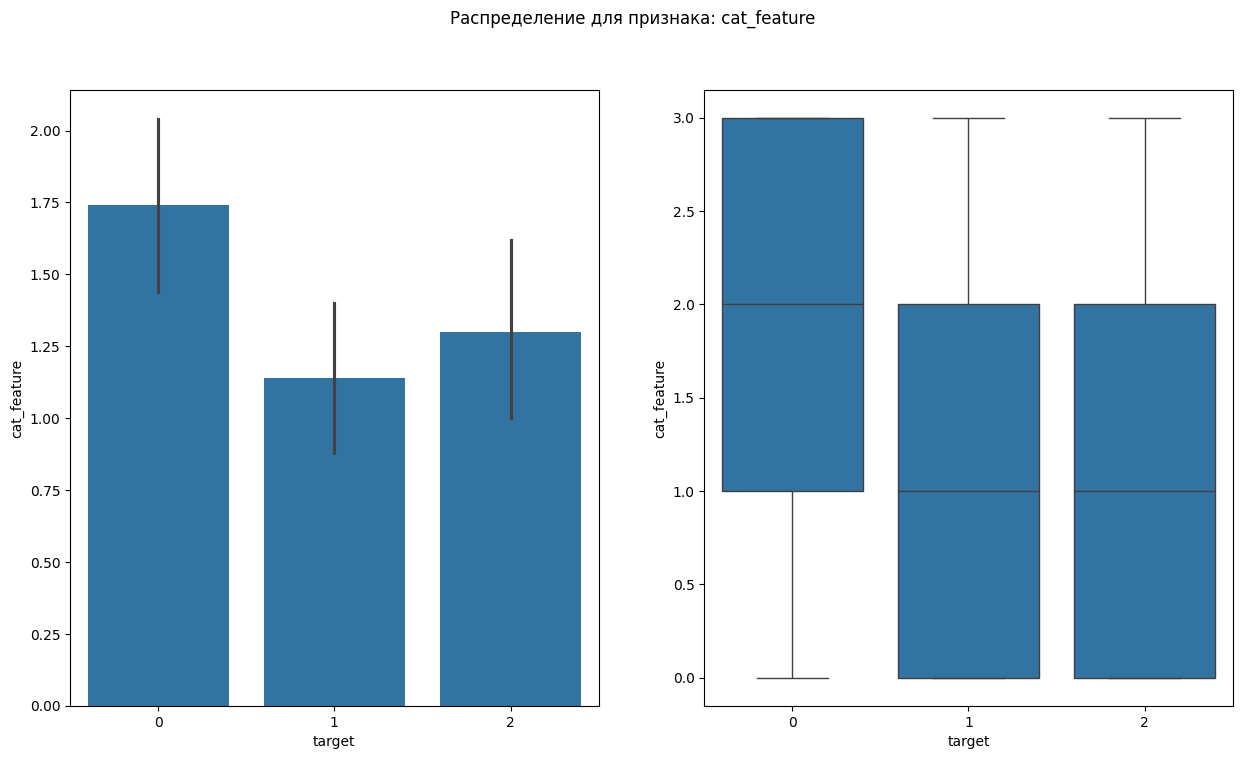

По тесту Спирмена: p-value = 0.0514. Нет значимой монотонной корреляции (ρ = -0.16).


In [45]:
get_ord_cont_plots("target", "cat_feature")

1. Корреляция Спирмена как оптимальный выбор для порядковых данных
Корреляция Спирмена (ρ) идеально подходит для анализа связи порядковых признаков по нескольким причинам. Во-первых, она оценивает монотонную, а не только линейную зависимость, что критически важно при работе с порядковыми шкалами, где расстояния между категориями могут быть неравномерными. Во-вторых, метод работает с рангами значений, а не с их абсолютными величинами, что делает его устойчивым к выбросам и нечувствительным к конкретному распределению данных. В-третьих, коэффициент Спирмена сохраняет свою интерпретируемость даже при наличии небольшого количества уникальных значений в порядковой переменной.

2. Визуализация через barplot и boxplot
Двойная визуализация обеспечивает всесторонний анализ данных. Barplot со средними значениями демонстрирует общий тренд изменения непрерывного признака при переходе между уровнями порядковой переменной. Boxplot дополняет эту информацию, показывая распределение значений внутри каждой категории, включая медиану, межквартильный размах и выбросы. Особенно важно, что при правильном упорядочивании категорий на оси X (соответствующем их естественному порядку) такие графики могут визуально подтверждать или опровергать монотонность зависимости.